# Data Warehouse con PostgreSQL y Python  

Extracción del conocimiento de Base de Datos-- Producto 1er Parcial

Universidad Tecnólogica del Centro de Veracruz

Profesora: Maria Reina Zarate Nava

Contenido

1.- Instalación de Dependencias y conexión 

2.- Creacion del esquema estrella en PostgreSQL

3.- Generacion y Carga de Datos (ETL)

4.- Consultas SQL y Analíticas

5.- Visualizaciones con Matplotlib

In [43]:
import pandas as pd

In [44]:
import numpy as np

In [45]:
import matplotlib.pyplot as plt

In [46]:
import matplotlib.ticker as mticker

In [47]:
import seaborn as sns

In [48]:
from sqlalchemy import create_engine, text

In [49]:
from faker import Faker

In [50]:
import random

In [51]:
from datetime import datetime, timedelta

In [52]:
import warnings

In [53]:
warnings.filterwarnings('ignore')

In [54]:
# CONFIGURACIÓN DE CONEXIÓN
# Ajusta estos valores según tu instalación de PostgreSQL
DB_USER     = 'postgres'
DB_PASSWORD = '1234'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'dw_ventas'

In [55]:
CONNECTION_STRING = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

In [56]:
engine = create_engine(CONNECTION_STRING)
print('Motor SQLAlchemy creado correctamente.')

Motor SQLAlchemy creado correctamente.


In [57]:
# Prueba de conexión
with engine.connect() as conn:
    result = conn.execute(text('SELECT version()'))
    print('Conexión exitosa a PostgreSQL:', result.fetchone()[0])

Conexión exitosa a PostgreSQL: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35226, 64-bit


# 2.- Creacion del esquema estrella en PostgreSQL

Se implementaran las siguientes Tablas

In [58]:
DDL_SCHEMA = """
-- Limpiar tablas si ya existen (útil para re-ejecutar)
DROP TABLE IF EXISTS fact_ventas CASCADE;
DROP TABLE IF EXISTS dim_tiempo CASCADE;
DROP TABLE IF EXISTS dim_cliente CASCADE;
DROP TABLE IF EXISTS dim_producto CASCADE;

-- ── DIMENSIÓN TIEMPO 
CREATE TABLE dim_tiempo (
    id_tiempo    SERIAL PRIMARY KEY,
    fecha        DATE        NOT NULL UNIQUE,
    anio         SMALLINT    NOT NULL,
    trimestre    SMALLINT    NOT NULL,  -- 1..4
    mes          SMALLINT    NOT NULL,  -- 1..12
    nombre_mes   VARCHAR(20) NOT NULL,
    semana       SMALLINT    NOT NULL,
    dia          SMALLINT    NOT NULL,
    dia_semana   VARCHAR(15) NOT NULL
);

-- ── DIMENSIÓN CLIENTE 
CREATE TABLE dim_cliente (
    id_cliente   SERIAL PRIMARY KEY,
    nombre       VARCHAR(120) NOT NULL,
    ciudad       VARCHAR(80)  NOT NULL,
    estado       VARCHAR(60)  NOT NULL,
    segmento     VARCHAR(30)  NOT NULL   -- Consumidor / Corporativo / Gobierno
);

-- ── DIMENSIÓN PRODUCTO 
CREATE TABLE dim_producto (
    id_producto      SERIAL PRIMARY KEY,
    nombre_producto  VARCHAR(150) NOT NULL,
    categoria        VARCHAR(60)  NOT NULL,
    subcategoria     VARCHAR(60)  NOT NULL,
    precio_unitario  NUMERIC(10,2) NOT NULL
);

-- ── TABLA DE HECHOS: VENTAS 
CREATE TABLE fact_ventas (
    id_venta     SERIAL PRIMARY KEY,
    id_tiempo    INT  NOT NULL REFERENCES dim_tiempo(id_tiempo),
    id_cliente   INT  NOT NULL REFERENCES dim_cliente(id_cliente),
    id_producto  INT  NOT NULL REFERENCES dim_producto(id_producto),
    cantidad     SMALLINT      NOT NULL,
    descuento    NUMERIC(4,2)  NOT NULL DEFAULT 0.00,
    monto_total  NUMERIC(12,2) NOT NULL
);
"""

In [59]:
with engine.connect() as conn:
    conn.execute(text(DDL_SCHEMA))
    conn.commit()

print('Esquema estrella creado exitosamente en PostgreSQL.')

Esquema estrella creado exitosamente en PostgreSQL.


# 3.- Generacion y Carga de Datos (ETL)

3.1 .- Generación de datos simulados con Faker

In [60]:
# ── ETL: Dimensión Tiempo (todo el año 2024) 
import locale
MESES_ES = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
            'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
DIAS_ES  = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']


In [61]:
start = datetime(2024, 1, 1)
end   = datetime(2024, 12, 31)
fechas = pd.date_range(start, end)

In [62]:
df_tiempo = pd.DataFrame({
    'fecha':      fechas,
    'anio':       fechas.year,
    'trimestre':  fechas.quarter,
    'mes':        fechas.month,
    'nombre_mes': [MESES_ES[m-1] for m in fechas.month],
    'semana':     fechas.isocalendar().week.astype(int),
    'dia':        fechas.day,
    'dia_semana': [DIAS_ES[d] for d in fechas.dayofweek],
})

In [63]:
with engine.connect() as conn:
    conn.execute(text("TRUNCATE TABLE fact_ventas, dim_tiempo, dim_cliente, dim_producto RESTART IDENTITY CASCADE;"))
    conn.commit()
print('Tablas limpiadas.')

Tablas limpiadas.


In [64]:
df_tiempo.to_sql('dim_tiempo', engine, if_exists='append', index=False)
print(f'dim_tiempo cargada: {len(df_tiempo)} registros.')
df_tiempo.head(3)

dim_tiempo cargada: 366 registros.


,fecha,anio,trimestre,mes,nombre_mes,semana,dia,dia_semana
2024-01-01,2024-01-01,2024,1,1,Enero,1,1,Lunes
2024-01-02,2024-01-02,2024,1,1,Enero,1,2,Martes
2024-01-03,2024-01-03,2024,1,1,Enero,1,3,Miércoles


In [65]:
# ETL: Dimensión Cliente
fake = Faker('es_MX')
Faker.seed(42)
random.seed(42)

In [66]:
CIUDADES_MX = [
    ('Ciudad de México','CDMX'), ('Guadalajara','Jalisco'), ('Monterrey','Nuevo León'),
    ('Puebla','Puebla'), ('Tijuana','Baja California'), ('Mérida','Yucatán'),
    ('Veracruz','Veracruz'), ('Córdoba','Veracruz'), ('Xalapa','Veracruz'),
    ('León','Guanajuato'), ('Cancún','Quintana Roo'), ('Querétaro','Querétaro')
]

In [67]:
SEGMENTOS = ['Consumidor', 'Corporativo', 'Gobierno']

In [68]:
clientes = []
for _ in range(200):
    ciudad, estado = random.choice(CIUDADES_MX)
    clientes.append({
        'nombre':   fake.name(),
        'ciudad':   ciudad,
        'estado':   estado,
        'segmento': random.choices(SEGMENTOS, weights=[60,30,10])[0]
    })

In [69]:
df_clientes = pd.DataFrame(clientes)
df_clientes.to_sql('dim_cliente', engine, if_exists='append', index=False)
print(f'dim_cliente cargada: {len(df_clientes)} registros.')
df_clientes.head(3)

dim_cliente cargada: 200 registros.


,nombre,ciudad,estado,segmento
0,Alberto Hernán Guevara,Cancún,Quintana Roo,Consumidor
1,Darío Canales,Querétaro,Querétaro,Consumidor
2,Araceli Villanueva,Puebla,Puebla,Consumidor


In [70]:
# ETL: Dimensión Producto
CATALOGO = [
    ('Laptop Lenovo IdeaPad',      'Tecnología',  'Computadoras',   12500),
    ('Monitor LG 24"',             'Tecnología',  'Monitores',       3200),
    ('Teclado Mecánico Redragon',  'Tecnología',  'Periféricos',      850),
    ('Mouse Logitech MX Master',   'Tecnología',  'Periféricos',     1450),
    ('Auriculares Sony WH-1000',   'Tecnología',  'Audio',           4200),
    ('Silla Ergonómica DXRacer',   'Muebles',     'Sillas de Oficina',5800),
    ('Escritorio L Ejecutivo',     'Muebles',     'Escritorios',     7200),
    ('Archivero 4 gavetas',        'Muebles',     'Almacenamiento',  2800),
    ('Resma de Papel A4',          'Papelería',   'Papel',             95),
    ('Bolígrafos BIC (caja 12)',   'Papelería',   'Escritura',        120),
    ('Carpetas Arcoíris (pack)',   'Papelería',   'Organización',     180),
    ('Impresora HP LaserJet',      'Tecnología',  'Impresoras',      5500),
    ('Tablet Samsung Galaxy',      'Tecnología',  'Tablets',         6800),
    ('Webcam Logitech C920',       'Tecnología',  'Periféricos',     1800),
    ('Proyector Epson SVGA',       'Tecnología',  'Proyectores',    11000),
]

In [71]:
df_productos = pd.DataFrame(CATALOGO, columns=['nombre_producto','categoria','subcategoria','precio_unitario'])
df_productos.to_sql('dim_producto', engine, if_exists='append', index=False)
print(f'dim_producto cargada: {len(df_productos)} registros.')
df_productos

dim_producto cargada: 15 registros.


,nombre_producto,categoria,subcategoria,precio_unitario
0,Laptop Lenovo IdeaPad,Tecnología,Computadoras,12500
1,"Monitor LG 24""",Tecnología,Monitores,3200
2,Teclado Mecánico Redragon,Tecnología,Periféricos,850
3,Mouse Logitech MX Master,Tecnología,Periféricos,1450
4,Auriculares Sony WH-1000,Tecnología,Audio,4200
5,Silla Ergonómica DXRacer,Muebles,Sillas de Oficina,5800
6,Escritorio L Ejecutivo,Muebles,Escritorios,7200
7,Archivero 4 gavetas,Muebles,Almacenamiento,2800
8,Resma de Papel A4,Papelería,Papel,95
9,Bolígrafos BIC (caja 12),Papelería,Escritura,120


In [72]:
# ETL: Tabla de Hechos (fact_ventas)
# Leer IDs generados por PostgreSQL
ids_tiempo   = pd.read_sql('SELECT id_tiempo FROM dim_tiempo', engine)['id_tiempo'].tolist()
ids_cliente  = pd.read_sql('SELECT id_cliente FROM dim_cliente', engine)['id_cliente'].tolist()
ids_producto = pd.read_sql('SELECT id_producto, precio_unitario FROM dim_producto', engine)

In [73]:
ventas = []
N_VENTAS = 5000

In [74]:
for _ in range(N_VENTAS):
    prod = ids_producto.sample(1).iloc[0]
    cantidad   = random.randint(1, 15)
    descuento  = random.choice([0.00, 0.05, 0.10, 0.15, 0.20])
    precio     = float(prod['precio_unitario'])
    monto      = round(cantidad * precio * (1 - descuento), 2)

    ventas.append({
        'id_tiempo':   random.choice(ids_tiempo),
        'id_cliente':  random.choice(ids_cliente),
        'id_producto': int(prod['id_producto']),
        'cantidad':    cantidad,
        'descuento':   descuento,
        'monto_total': monto
    })

In [75]:
df_ventas = pd.DataFrame(ventas)
df_ventas.to_sql('fact_ventas', engine, if_exists='append', index=False, chunksize=500)
print(f'fact_ventas cargada: {len(df_ventas)} registros.')
df_ventas.describe()

fact_ventas cargada: 5000 registros.


,id_tiempo,id_cliente,id_producto,cantidad,descuento,monto_total
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,185.699200,100.247000,7.888200,7.956000,0.101670,29732.518200
std,105.045655,58.031966,4.325164,4.302065,0.070836,34368.245728
min,1.000000,1.000000,1.000000,1.000000,0.000000,76.000000
25%,94.000000,49.000000,4.000000,4.000000,0.050000,3780.000000
50%,186.000000,99.500000,8.000000,8.000000,0.100000,16800.000000
75%,276.000000,152.000000,12.000000,12.000000,0.150000,43520.000000
max,366.000000,200.000000,15.000000,15.000000,0.200000,187500.000000


# 4.- Consultas SQL y Analíticas

In [76]:
# Consulta 1: Ventas totales por mes 
q_mensual = """
SELECT
    t.mes,
    t.nombre_mes,
    COUNT(f.id_venta)          AS num_transacciones,
    SUM(f.cantidad)            AS unidades_vendidas,
    ROUND(SUM(f.monto_total), 2) AS ingreso_total
FROM fact_ventas f
JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
GROUP BY t.mes, t.nombre_mes
ORDER BY t.mes;
"""
df_mensual = pd.read_sql(q_mensual, engine)
print('Ventas por mes:')
df_mensual

Ventas por mes:


,mes,nombre_mes,num_transacciones,unidades_vendidas,ingreso_total
0,1,Enero,393,3116,10921885.75
1,2,Febrero,374,2896,10870007.75
2,3,Marzo,448,3803,14310199.75
3,4,Abril,384,2981,11448801.25
4,5,Mayo,417,3279,12497386.75
5,6,Junio,436,3453,12879748.00
6,7,Julio,420,3160,12773468.00
7,8,Agosto,444,3659,14022724.75
8,9,Septiembre,422,3389,12803966.75
9,10,Octubre,402,3285,11228617.50


In [78]:
# Consulta 3: Ventas por ciudad 
q_ciudad = """
SELECT
    c.ciudad,
    c.estado,
    COUNT(f.id_venta)            AS num_ventas,
    ROUND(SUM(f.monto_total), 2) AS ingreso_total
FROM fact_ventas f
JOIN dim_cliente c ON f.id_cliente = c.id_cliente
GROUP BY c.ciudad, c.estado
ORDER BY ingreso_total DESC
LIMIT 12;
"""
df_ciudad = pd.read_sql(q_ciudad, engine)
print('Ventas por ciudad:')
df_ciudad

Ventas por ciudad:


,ciudad,estado,num_ventas,ingreso_total
0,Xalapa,Veracruz,492,15479722.50
1,Veracruz,Veracruz,534,15300116.75
2,Puebla,Puebla,464,14753141.00
3,Monterrey,Nuevo León,481,14597846.50
4,Guadalajara,Jalisco,476,14097384.75
5,Cancún,Quintana Roo,429,13214046.00
6,Ciudad de México,CDMX,466,12617102.25
7,Tijuana,Baja California,363,11966928.00
8,Mérida,Yucatán,357,10774186.50
9,Córdoba,Veracruz,368,10284509.50


In [79]:
# Consulta 4: Ingreso por categoría de producto
q_categoria = """
SELECT
    p.categoria,
    ROUND(SUM(f.monto_total), 2) AS ingreso_total,
    ROUND(SUM(f.monto_total) * 100.0 / SUM(SUM(f.monto_total)) OVER (), 1) AS pct
FROM fact_ventas f
JOIN dim_producto p ON f.id_producto = p.id_producto
GROUP BY p.categoria
ORDER BY ingreso_total DESC;
"""
df_cat = pd.read_sql(q_categoria, engine)
print('Ventas por categoría:')
df_cat

Ventas por categoría:


,categoria,ingreso_total,pct
0,Tecnología,110370062.5,74.2
1,Muebles,37367790.0,25.1
2,Papelería,924738.5,0.6


# 5.- Visualizaciones con Matplotlib

In [80]:
# Configuración global de estilo
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'figure.facecolor':   'white',
})
COLORES = ['#1E7BB0','#2ECC71','#E74C3C','#F39C12','#9B59B6','#1ABC9C']
print('Configuración de Matplotlib lista')

Configuración de Matplotlib lista


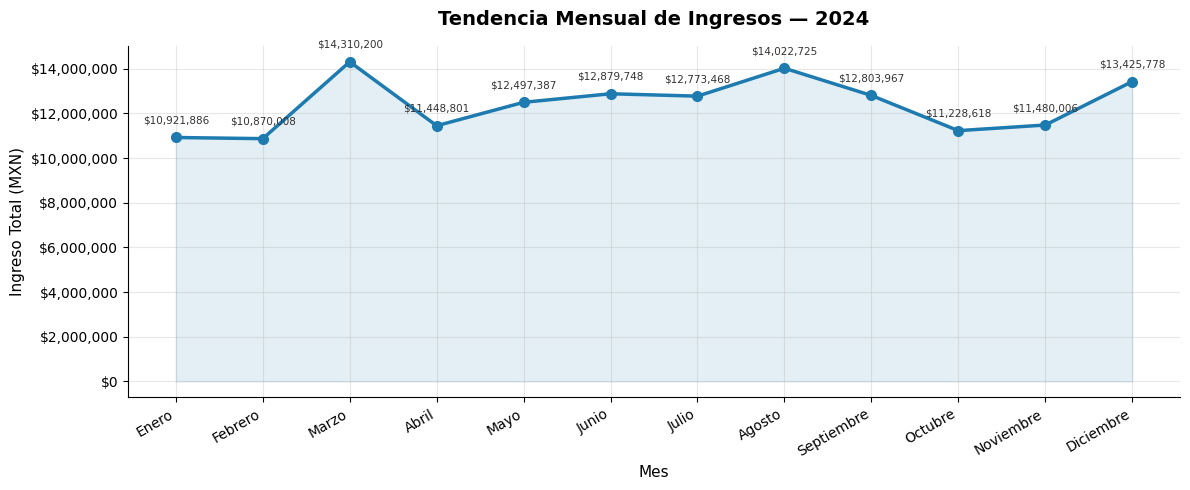

Gráfico guardado: grafico_tendencia_mensual.png


In [81]:
# Gráfico 1: Línea — Tendencia mensual de ingresos
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_mensual['nombre_mes'], df_mensual['ingreso_total'],
        marker='o', linewidth=2.5, color=COLORES[0], markersize=7, label='Ingreso total')
ax.fill_between(range(len(df_mensual)), df_mensual['ingreso_total'], alpha=0.12, color=COLORES[0])

for i, row in df_mensual.iterrows():
    ax.annotate(f"${row['ingreso_total']:,.0f}",
                xy=(i, row['ingreso_total']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=7.5, color='#333')

ax.set_title('Tendencia Mensual de Ingresos — 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Ingreso Total (MXN)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(range(len(df_mensual)), df_mensual['nombre_mes'], rotation=30, ha='right')
plt.tight_layout()
plt.savefig('grafico_tendencia_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: grafico_tendencia_mensual.png')

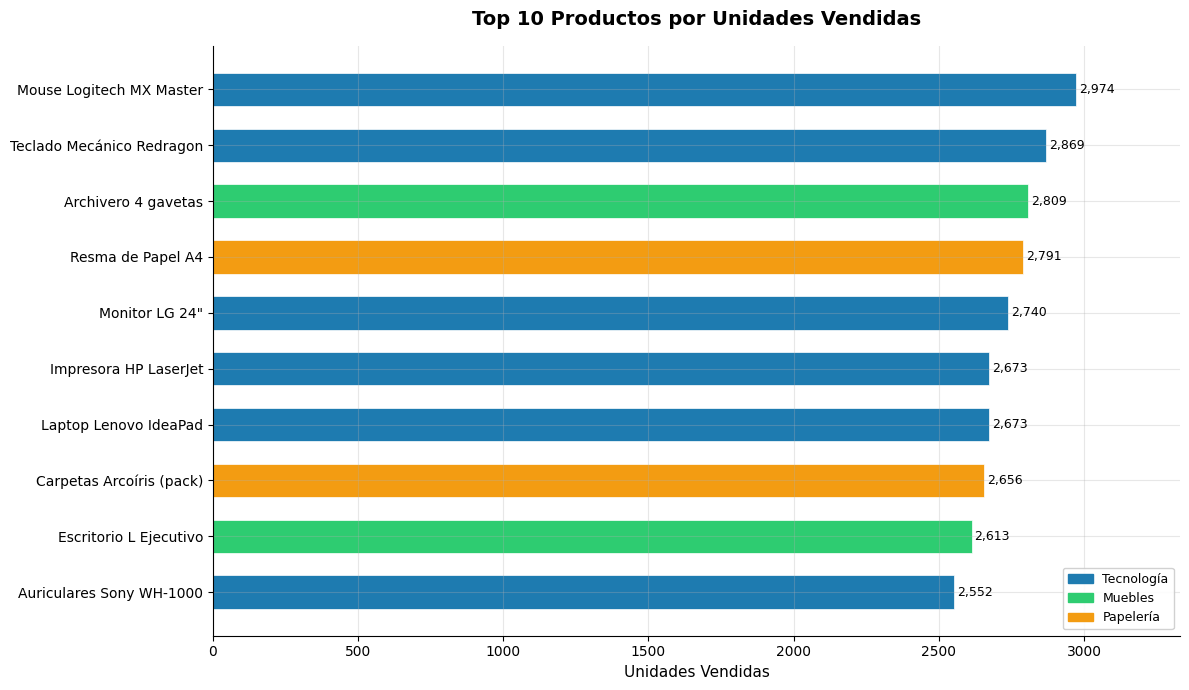

Gráfico guardado: grafico_top_productos.png


In [82]:
# Gráfico 2: Barras horizontales — Top 10 productos
fig, ax = plt.subplots(figsize=(12, 7))  # más ancho y alto

colores_barras = [COLORES[0] if c == 'Tecnología' else COLORES[1] if c == 'Muebles' else COLORES[3]
                  for c in df_top_prod['categoria']]

barras = ax.barh(df_top_prod['nombre_producto'], df_top_prod['unidades_vendidas'],
                 color=colores_barras, edgecolor='white', linewidth=0.5, height=0.6)

for barra in barras:
    w = barra.get_width()
    ax.text(w + 10, barra.get_y() + barra.get_height()/2,
            f'{int(w):,}', va='center', fontsize=9)

# Dar espacio extra a la derecha para los números
ax.set_xlim(0, df_top_prod['unidades_vendidas'].max() * 1.12)

ax.set_title('Top 10 Productos por Unidades Vendidas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unidades Vendidas', fontsize=11)
ax.invert_yaxis()

from matplotlib.patches import Patch
leyenda = [Patch(color=COLORES[0], label='Tecnología'),
           Patch(color=COLORES[1], label='Muebles'),
           Patch(color=COLORES[3], label='Papelería')]

# Leyenda dentro del gráfico, esquina inferior derecha sin tapar barras
ax.legend(handles=leyenda, loc='lower right', fontsize=9,
          framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('grafico_top_productos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: grafico_top_productos.png')

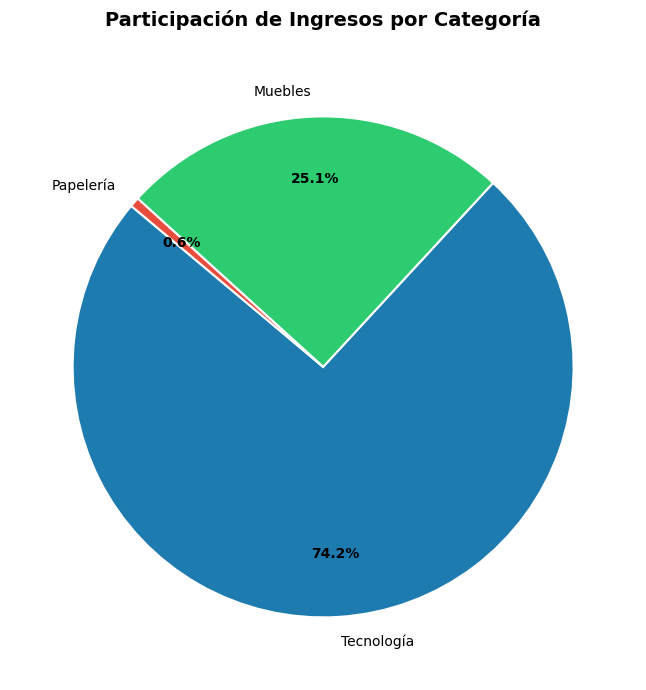

Gráfico guardado: grafico_categorias.png


In [83]:
#Gráfico 3: Pastel — Ingreso por categoría
fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    df_cat['ingreso_total'],
    labels=df_cat['categoria'],
    autopct='%1.1f%%',
    startangle=140,
    colors=COLORES[:len(df_cat)],
    pctdistance=0.75,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax.set_title('Participación de Ingresos por Categoría', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('grafico_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: grafico_categorias.png')

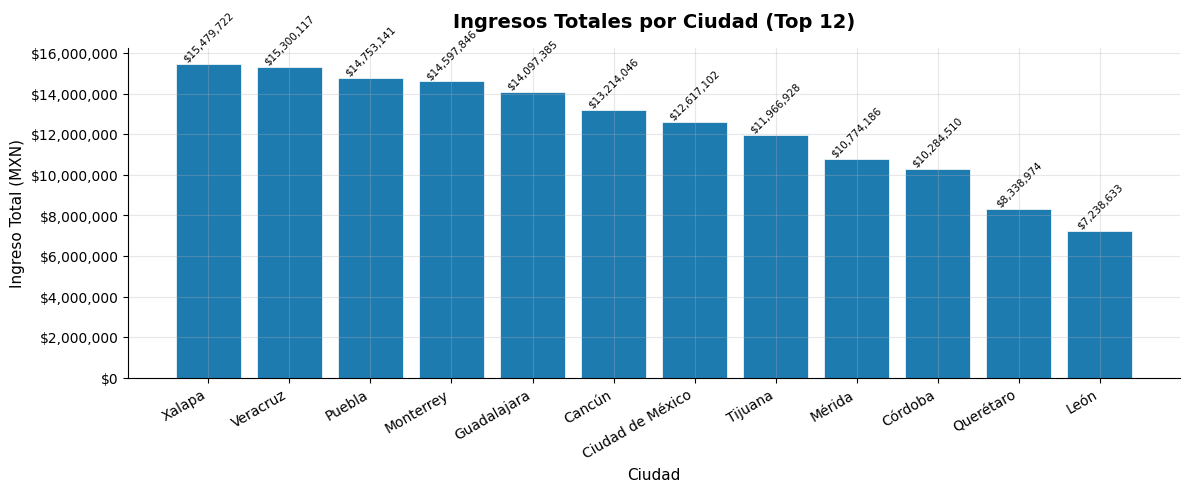

Gráfico guardado: grafico_ciudades.png


In [84]:
#Gráfico 4: Barras — Ingresos por ciudad (Top 12) 
fig, ax = plt.subplots(figsize=(12, 5))

barras = ax.bar(df_ciudad['ciudad'], df_ciudad['ingreso_total'],
                color=COLORES[0], edgecolor='white', linewidth=0.5)

for barra in barras:
    h = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, h + 5000,
            f'${h:,.0f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_title('Ingresos Totales por Ciudad (Top 12)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ciudad', fontsize=11)
ax.set_ylabel('Ingreso Total (MXN)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('grafico_ciudades.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: grafico_ciudades.png')